**Transformation de la DB des urls en dataframe pandas**

#### données de Donald Trump

In [28]:
import sqlite3
import pandas as pd
import os

db_path = "..\\data\\speeches.db"
conn=sqlite3.connect(db_path)
trump=pd.read_sql_query("Select * from Speeches",conn)
conn.close()

In [29]:
trump

,id,url,title,date,nbr_sentences,nbr_words,nbr_seconds,categories
0,1,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Service Members...,"October 5, 2025",693,6902,2636,"[""Armed Forces"", ""Waterway and Maritime Transp..."
1,2,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Military Leader...,"September 30, 2025",1031,12529,4261,"[""Politics"", ""Military Equipment"", ""Government..."
2,3,https://rollcall.com/factbase/trump/transcript...,Speech: JD Vance Discusses Tax Policy and Publ...,"September 24, 2025",,,,"[""Government"", ""Crime"", ""Police"", ""Law Enforce..."
3,4,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses the 80th Sessio...,"September 23, 2025",579,8317,3398,"[""Economy, Business and Finance"", ""Crime"", ""In..."
4,5,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses a Memorial for ...,"September 21, 2025",458,5631,2472,"[""Crime"", ""Religion"", ""Crime, Law and Justice""..."
...,...,...,...,...,...,...,...,...
880,881,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Delivers a Speech at a Te...,"April 16, 2011",716,6810,2727,[]
881,882,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Attends a Tea Party Rally...,"April 16, 2011",697,6792,2741,"[""Human Interest"", ""Economy, Business and Fina..."
882,883,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses the CPAC Conven...,"February 10, 2011",147,1654,827,"[""Company Information"", ""Market and Exchange"",..."
883,884,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump at the Cuban-American Nat...,"Miami, FL - November 15, 1999",70,1316,661,"[""Human Rights"", ""Politics""]"


### données de Joe Biden et Kamala Haris

In [ ]:
import pandas as pd
import re
df = pd.read_parquet('../data/other_transcriptions_cleaned.parquet', engine='fastparquet')
df['text']=df['text'].str.replace(r"\[.*?\]","",regex=True,flags=re.DOTALL).str.strip()

In [27]:
import sqlite3
import pandas as pd

db_path = r"C:\Users\Paulkengne\Desktop\2AD\Getting-in-Trump-s-Head\data\other_candidate.db"
conn = sqlite3.connect(db_path)
other_cand = pd.read_sql_query("SELECT * FROM Speeches", conn)
conn.close()

other_cand.head()

,id,url,title,date,nbr_sentences,nbr_words,nbr_seconds,categories,person_name
0,1,https://rollcall.com/factbase/harris/transcrip...,Speech: Kamala Harris Holds a Campaign Rally i...,"October 26, 2024",254,3331,1881,"[""Human Rights"", ""Election"", ""Politics"", ""Labo...",Kamala Harris
1,2,https://rollcall.com/factbase/harris/transcrip...,Speech: Kamala Harris Delivers Remarks at a Ca...,"October 19, 2024",260,3091,1783,"[""Politics"", ""Human Rights""]",Kamala Harris
2,3,https://rollcall.com/factbase/harris/transcrip...,Speech: Kamala Harris Addresses a Campaign Ral...,"October 18, 2024",272,3546,2010,"[""Employment"", ""Justice and Rights"", ""Human Ri...",Kamala Harris
3,4,https://rollcall.com/factbase/harris/transcrip...,Speech: Kamala Harris Delivers Remarks at the ...,"September 25, 2024",221,4278,2378,"[""Macro Economics"", ""Economy, Business and Fin...",Kamala Harris
4,5,https://rollcall.com/factbase/harris/transcrip...,Speech: Kamala Harris Holds a Campaign Event i...,"September 4, 2024",220,3178,1561,"[""Employment"", ""Prison"", ""Justice and Rights"",...",Kamala Harris


### Merging of both database

In [31]:
import pandas as pd

trump["person_name"]= "Donalt Trump"

df = pd.concat([df1, other_cand], ignore_index=True)
df

,id,url,title,date,nbr_sentences,nbr_words,nbr_seconds,categories,person_name
0,1,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Service Members...,2025-10-05 00:00:00,693.0,6902.0,2636.0,"[Armed Forces, Waterway and Maritime Transport...",Donalt Trump
1,2,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Military Leader...,2025-09-30 00:00:00,1031.0,12529.0,4261.0,"[Politics, Military Equipment, Government, Arm...",Donalt Trump
2,3,https://rollcall.com/factbase/trump/transcript...,Speech: JD Vance Discusses Tax Policy and Publ...,2025-09-24 00:00:00,769.846416,7915.070535,3241.950231,"[Government, Crime, Police, Law Enforcement, P...",Donalt Trump
3,4,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses the 80th Sessio...,2025-09-23 00:00:00,579.0,8317.0,3398.0,"[Economy, Business and Finance, Crime, Industr...",Donalt Trump
4,5,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses a Memorial for ...,2025-09-21 00:00:00,458.0,5631.0,2472.0,"[Crime, Religion, Crime, Law and Justice, Poli...",Donalt Trump
...,...,...,...,...,...,...,...,...,...
938,54,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Addresses the United Nations...,"September 21, 2022",217,3734,1746,"[""Summit"", ""Diplomacy"", ""Politics"", ""Human Rig...",Joe Biden
939,55,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Celebrates Labor Day at an E...,"September 5, 2022",379,4560,1965,"[""Labor"", ""Medical Staff"", ""Employment"", ""Heal...",Joe Biden
940,56,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Delivers a Primetime Address...,"September 1, 2022",223,2971,1455,"[""Election"", ""Politics (General)"", ""Parties an...",Joe Biden
941,57,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Delivers an Address on Reduc...,"August 30, 2022",410,4954,2080,"[""Local Authority"", ""Politics"", ""Police"", ""Cri...",Joe Biden


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             943 non-null    int64 
 1   url            943 non-null    object
 2   title          943 non-null    object
 3   date           922 non-null    object
 4   nbr_sentences  943 non-null    object
 5   nbr_words      943 non-null    object
 6   nbr_seconds    943 non-null    object
 7   categories     943 non-null    object
 8   person_name    943 non-null    object
dtypes: int64(1), object(8)
memory usage: 66.4+ KB


### Convertion of some variables into numeric/datetime

In [43]:
df["nbr_words"]=pd.to_numeric(df["nbr_words"], errors= "coerce",downcast="integer")
df["nbr_sentences"]=pd.to_numeric(df["nbr_sentences"], errors="coerce", downcast="integer")
df["nbr_seconds"]=pd.to_numeric(df["nbr_seconds"], errors="coerce", downcast="integer")

df["date"]=pd.to_datetime(df["date"], errors="coerce")

### Checking of the database and treatment of missing value

In [44]:
df.isna().sum().sort_values(ascending=False)*100/df1.shape[0]  # sort by percentage of missing values

date             2.485876
nbr_seconds      0.112994
nbr_sentences    0.112994
nbr_words        0.112994
id               0.000000
url              0.000000
title            0.000000
categories       0.000000
person_name      0.000000
dtype: float64

In [49]:
df.fillna({"nbr_sentences" : df1["nbr_sentences"].mean(),          # fill missing value by the mean 
            "nbr_seconds": df1["nbr_seconds"].mean(),
            "nbr_words": df1["nbr_words"].mean()
}, inplace=True)                                            

### Some basics statistics 

In [46]:
df.columns

Index(['id', 'url', 'title', 'date', 'nbr_sentences', 'nbr_words',
       'nbr_seconds', 'categories', 'person_name'],
      dtype='object')

In [53]:
comparison = df.groupby("person_name").agg(
    nbr_discours=("nbr_sentences", "count"),
    mots_moyens=("nbr_words", "mean"),
    duree_moyenne=("nbr_seconds", "mean")
).round(2)

print(comparison)


               nbr_discours  mots_moyens  duree_moyenne
person_name                                            
Donalt Trump            885      7915.07        3241.95
Joe Biden                40      5484.40        2303.50
Kamala Harris            18      2556.17        1516.39


In [59]:
number=df["person_name"].value_counts()
number

person_name
Donalt Trump     885
Joe Biden         40
Kamala Harris     18
Name: count, dtype: int64

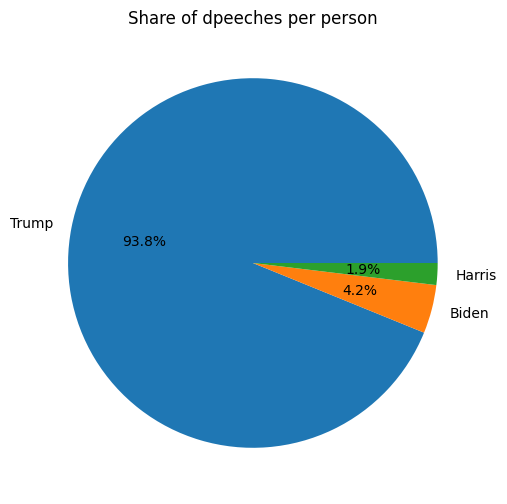

In [60]:
plt.figure(figsize=(6,6))
plt.subplot(111)

number=df["person_name"].value_counts()

plt.pie(number,labels=["Trump", "Biden", "Harris"], autopct="%1.1f%%")

plt.title("Share of dpeeches per person")

plt.show()

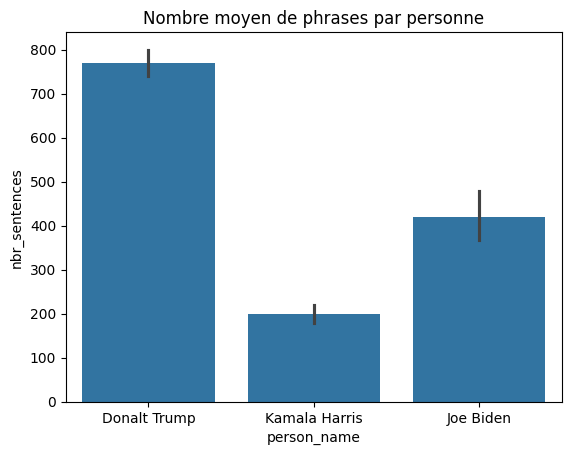

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.barplot(x="person_name", y="nbr_sentences", data=df)
plt.title("Nombre moyen de phrases par personne")
plt.show()

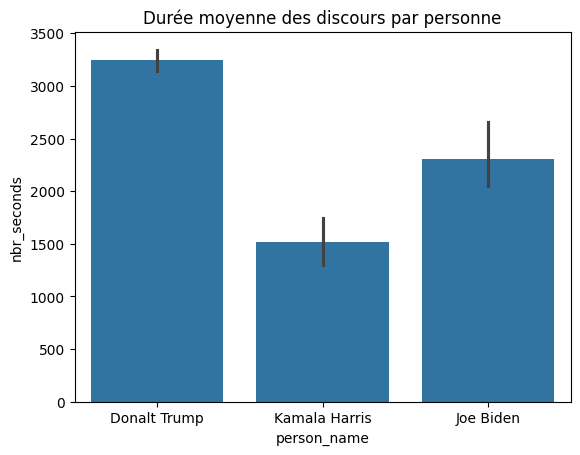

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.barplot(x="person_name", y="nbr_seconds", data=df)
plt.title("Durée moyenne des discours par personne")
plt.show()




### Wordcloud of categories

In [65]:
df["categories"].head(5)

0    [Armed Forces, Waterway and Maritime Transport...
1    [Politics, Military Equipment, Government, Arm...
2    [Government, Crime, Police, Law Enforcement, P...
3    [Economy, Business and Finance, Crime, Industr...
4    [Crime, Religion, Crime, Law and Justice, Poli...
Name: categories, dtype: object

In [69]:
# Vérifier le type
print(type(df.loc[0, 'categories']))

# Si c'est une liste, explode directement
#df_exploded = df.explode('categories').reset_index(drop=True)

# Exemple : compter le nombre de discours par catégorie
#df_exploded['categories'].value_counts()


<class 'list'>


In [72]:
import ast

def to_list(x):
    if isinstance(x, list):
        return x  # déjà une liste
    x = str(x)  # s'assurer que c'est une chaîne
    try:
        # essaie de transformer en liste si c'est une chaîne de liste
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        # sinon, on met la chaîne simple dans une liste
        return [x]

# Appliquer la fonction
df['categories'] = df['categories'].apply(to_list)

# Maintenant explode fonctionne correctement
df_exploded = df.explode('categories').reset_index(drop=True)

print(df_exploded['categories'])


0                          Armed Forces
1       Waterway and Maritime Transport
2                              Politics
3                    Military Equipment
4         Economy, Business and Finance
                     ...               
4710                         Employment
4711               Automotive Equipment
4712                             Unions
4713                           Politics
4714      Economy, Business and Finance
Name: categories, Length: 4715, dtype: object


In [74]:
df["categories"]

0      [Armed Forces, Waterway and Maritime Transport...
1      [Politics, Military Equipment, Government, Arm...
2      [Government, Crime, Police, Law Enforcement, P...
3      [Economy, Business and Finance, Crime, Industr...
4      [Crime, Religion, Crime, Law and Justice, Poli...
                             ...                        
938          [Summit, Diplomacy, Politics, Human Rights]
939    [Labor, Medical Staff, Employment, Health, Uni...
940    [Election, Politics (General), Parties and Mov...
941    [Local Authority, Politics, Police, Crime, Law...
942    [Macro Economics, Manufacturing and Engineerin...
Name: categories, Length: 943, dtype: object

In [80]:
df

,id,url,title,date,nbr_sentences,nbr_words,nbr_seconds,categories,person_name
0,1,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Service Members...,2025-10-05,693.000000,6902.000000,2636.000000,"[Armed Forces, Waterway and Maritime Transport...",Donalt Trump
1,2,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses Military Leader...,2025-09-30,1031.000000,12529.000000,4261.000000,"[Politics, Military Equipment, Government, Arm...",Donalt Trump
2,3,https://rollcall.com/factbase/trump/transcript...,Speech: JD Vance Discusses Tax Policy and Publ...,2025-09-24,769.846416,7915.070535,3241.950231,"[Government, Crime, Police, Law Enforcement, P...",Donalt Trump
3,4,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses the 80th Sessio...,2025-09-23,579.000000,8317.000000,3398.000000,"[Economy, Business and Finance, Crime, Industr...",Donalt Trump
4,5,https://rollcall.com/factbase/trump/transcript...,Speech: Donald Trump Addresses a Memorial for ...,2025-09-21,458.000000,5631.000000,2472.000000,"[Crime, Religion, Crime, Law and Justice, Poli...",Donalt Trump
...,...,...,...,...,...,...,...,...,...
938,54,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Addresses the United Nations...,2022-09-21,217.000000,3734.000000,1746.000000,"[Summit, Diplomacy, Politics, Human Rights]",Joe Biden
939,55,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Celebrates Labor Day at an E...,2022-09-05,379.000000,4560.000000,1965.000000,"[Labor, Medical Staff, Employment, Health, Uni...",Joe Biden
940,56,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Delivers a Primetime Address...,2022-09-01,223.000000,2971.000000,1455.000000,"[Election, Politics (General), Parties and Mov...",Joe Biden
941,57,https://rollcall.com/factbase/biden/transcript...,Speech: Joe Biden Delivers an Address on Reduc...,2022-08-30,410.000000,4954.000000,2080.000000,"[Local Authority, Politics, Police, Crime, Law...",Joe Biden


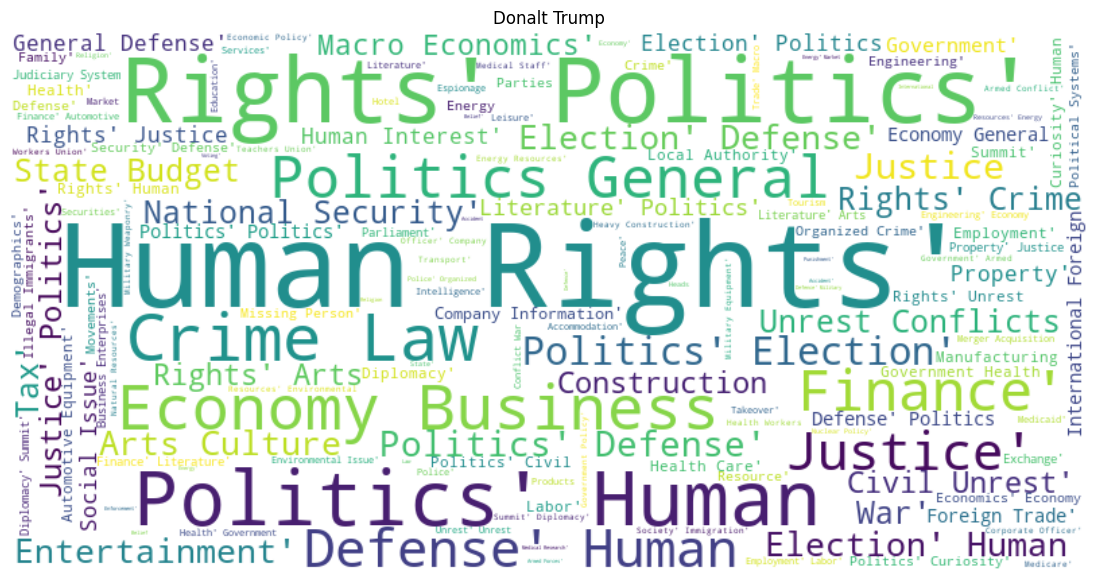

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df1=df[df["person_name"]=="Donalt Trump"]

text = " ".join(df1['categories'].dropna().astype(str))

mwe_list = ["human rights", "foreign policy", "climate change"]
for mwe in mwe_list:
    text = text.replace(mwe, mwe.replace(" ", "_"))

wordcloud = WordCloud(width=800, height=400, collocations=True, background_color="white").generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Donalt Trump")
plt.axis("off")
plt.show()

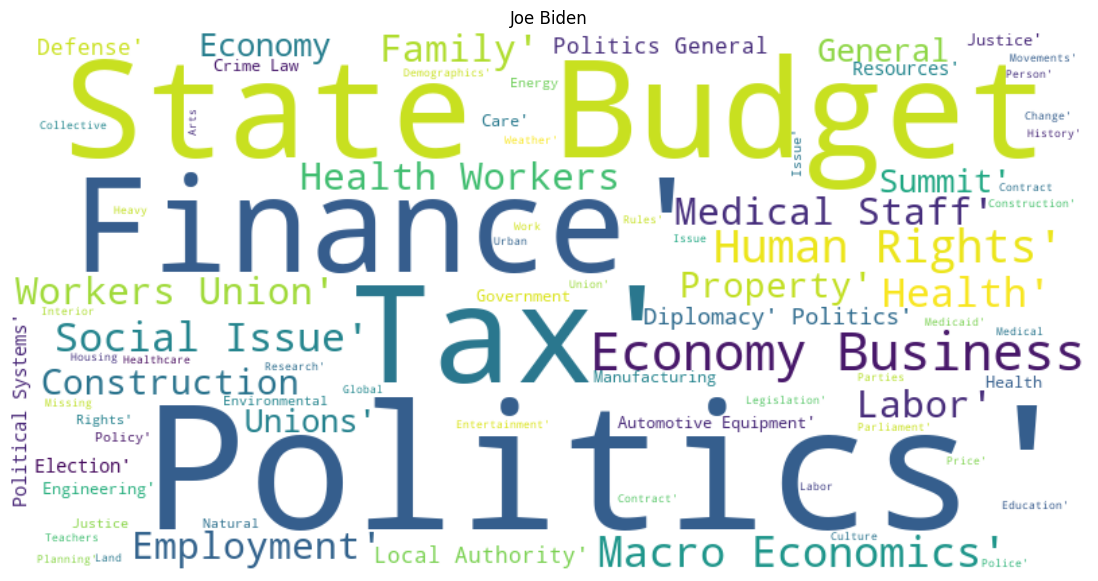

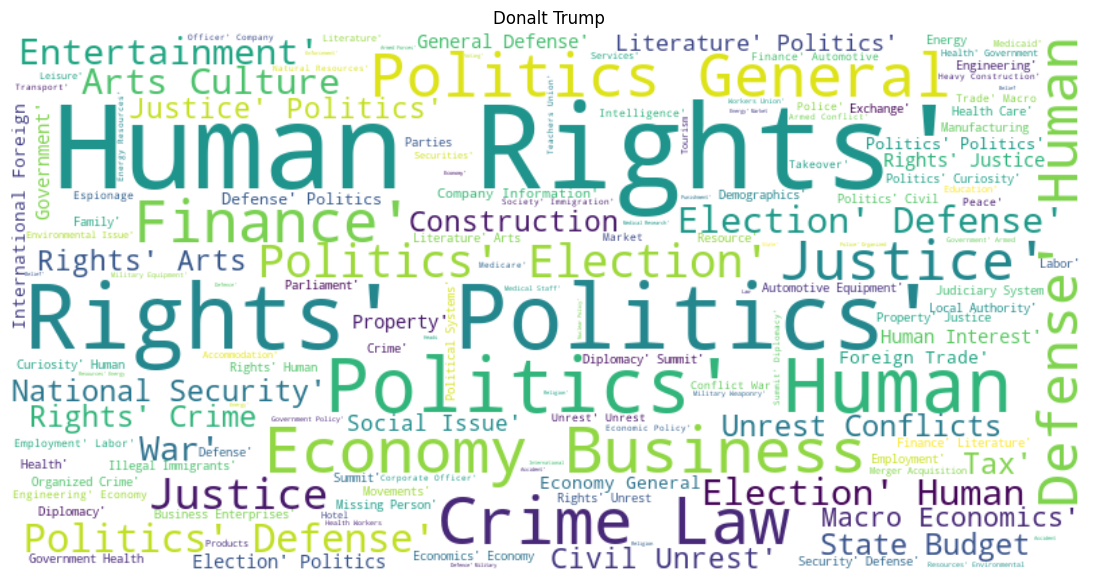

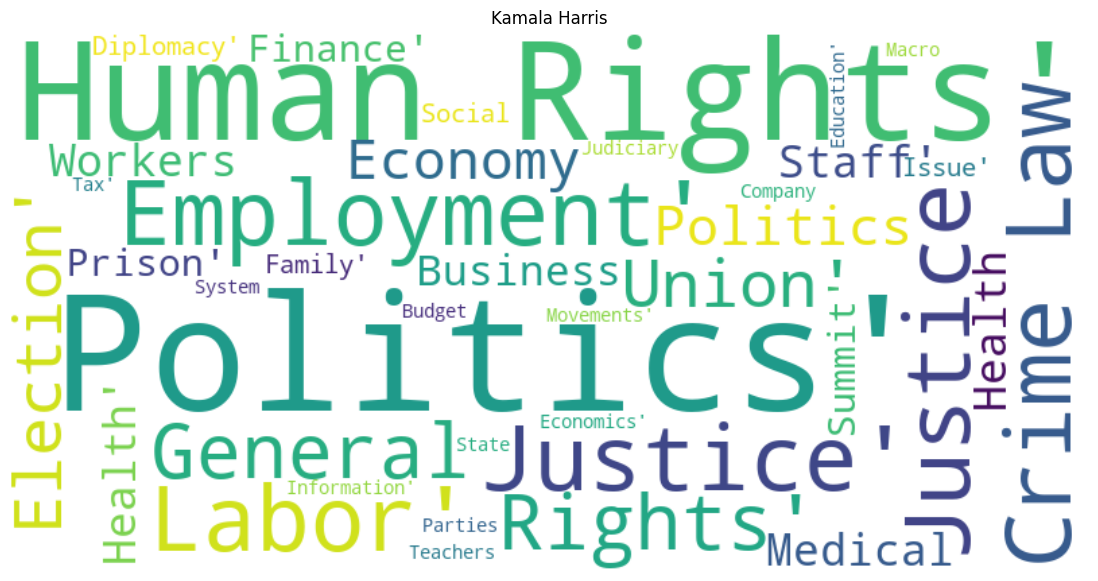

In [88]:
for nom in ["Joe Biden", "Donalt Trump", "Kamala Harris" ]:
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt

    df1=df[df["person_name"]==nom]

    text = " ".join(df1['categories'].dropna().astype(str))

    mwe_list = ["human rights", "foreign policy", "climate change"]
    for mwe in mwe_list:
        text = text.replace(mwe, mwe.replace(" ", "_"))

    wordcloud = WordCloud(width=800, height=400, collocations=True, background_color="white").generate(text)
    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(nom)
    plt.axis("off")
    plt.show()


### Percentage of each categorie

In [15]:
df_exploded["categories"].value_counts().sort_values(ascending=False)*100/df_exploded.shape[0]

categories
Politics                      19.034608
Human Rights                  15.163934
Defense                        9.198543
Election                       6.238616
Crime, Law and Justice         4.007286
                                ...    
Monument and Heritage Site     0.022769
International Law              0.022769
Disaster and Accident          0.022769
Transport Accident             0.022769
Road Accident                  0.022769
Name: count, Length: 158, dtype: float64